In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ---- project imports ----
from sim.frame import make_blank_frame
from sim.render import RenderConfig, render, plot_render_stages
from sim.camera import Camera
from sim.lens import Lens
from sim.mask import Mask
from sim.physics.noise import apply_noise

from sim.physics.stars import load_star_field

sky median (e-/px): 2.265517473220825
stars_post_psf max (e-/px): 4040.174072265625
final mean/var (small patch): 2.5967178344726562 111.2315902709961
catalog stars: 65263 | on-sensor: 517


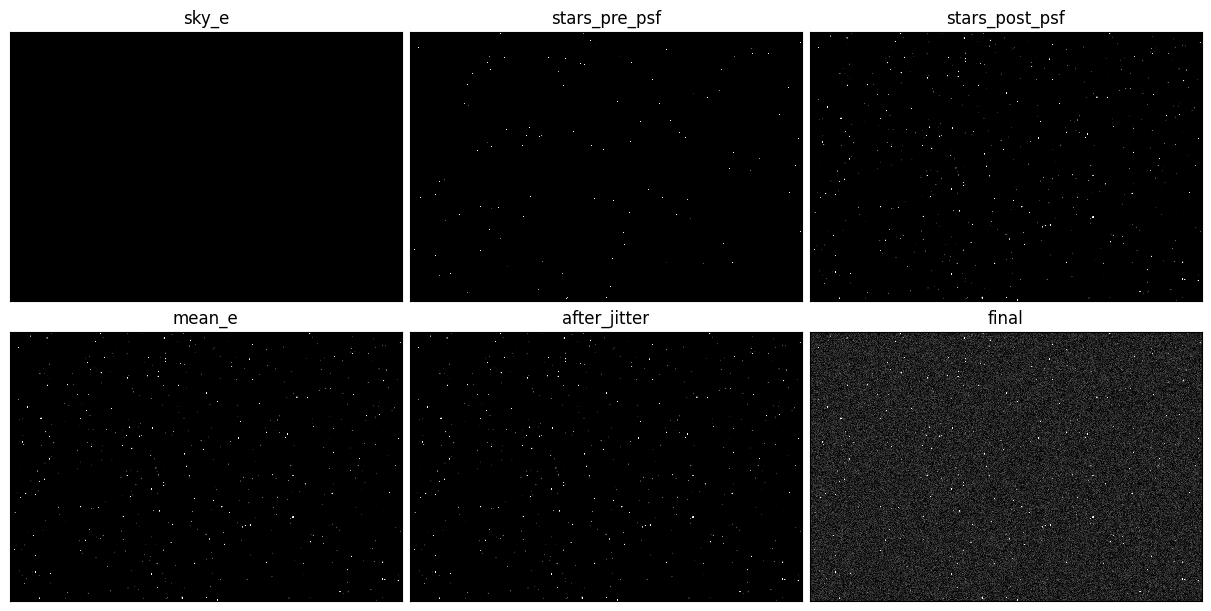

In [10]:
# ===============================
# End-to-end sanity test (mask pipeline in place, but mask is NO-OP)
# ===============================

STAR_CSV = "sim/physics/starfields/field2.csv"

# Pointing (match your downloaded field)
RA0_DEG  = 40.0
DEC0_DEG = 70.0
ROT_DEG  = 0.0

# Camera + lens
cam = Camera(
    nx=1920,
    ny=1080,
    pixel_um=3.75,
    read_noise_e=5,
    gain_e_per_adu=1.0,
    qe=0.6,
)

lens = Lens(
    focal_mm=120.0,
    f_number=2.0,
    transmission=0.9
)

# Blank frame
frame = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)

# Render config:
# - derived star ZP (zeropoint_e_per_s=0)
# - derived sky from mu (sky_e_per_px_s=0)
# - PSF + jitter + noise on
# - mask object present but kind="none" => no change (plumbing test)
cfg = RenderConfig(
    exposure_s=1.0,
    sky_e_per_px_s=0.0,
    sky_mu_mag_per_arcsec2=21.0,
    zeropoint_e_per_s=0.0,
    lambda_eff_nm=550.0,
    band_nm=90.0,

    psf_sigma_px=1.2,
    mask=Mask(kind="none"),

    jitter_pointing_rms=0.0,   # arcsec RMS; set e.g. 6.5 for ~1 px at your plate scale

    enable_psf=True,
    enable_jitter=False,
    enable_noise=True,

    seed=42
)

frame, res = render(frame, cfg, stars=STAR_CSV)

# Visualize stages (your updated plot_render_stages should be 2x3)
plot_render_stages(frame, res, cmap="gray", stretch="asinh", shared_scale=True)

# Quick numeric checks
print("sky median (e-/px):", float(np.median(res.sky_e)))
print("stars_post_psf max (e-/px):", float(np.max(res.stars_e_post_psf)))
print("final mean/var (small patch):",
      float(np.mean(res.final_e[200:400, 200:400])),
      float(np.var(res.final_e[200:400, 200:400])))

# Optional: confirm how many catalog stars land on sensor
sf = load_star_field(STAR_CSV)
x_px, y_px = frame.radec_to_pixel(sf.ra_deg, sf.dec_deg)
on = (x_px >= 0) & (x_px < cam.nx) & (y_px >= 0) & (y_px < cam.ny)
print("catalog stars:", len(sf.ra_deg), "| on-sensor:", int(on.sum()))